## Process topo split results

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
client = start_cluster(8, 24)
client_ip_and_port(client)

2025-06-13 12:12:22,311 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7fded15b3bf0>>, <Task finished name='Task-16' coro=<SpecCluster._correct_state_internal() done, defined at /uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/deploy/spec.py:346> exception=RuntimeError('Command exited with non-zero exit code.\nExit code: 1\nCommand:\nsbatch /scratch/local/u1037042/4756122/tmpnrujdi7z.sh\nstdout:\n\nstderr:\nsbatch: error: Batch job submission failed: Invalid qos specification\n\n')>)
Traceback (most recent call last):
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/tornado/ioloop.py", line 750, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/e

10.242.76.198:8787


In [11]:
# paths
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES")
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES/net_solar_dsw3/wy2022")
# net_dswrf.MST.20211110.nc
SHARED_STORE2 = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit")
# toposplit_20220218.nc

SHARED_STORE_RUN = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit")
# erw_spires_dsw3_dlwrf/wy2022/erw_50m

SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')
SNOTEL_DIR = DATA_DIR.joinpath( 'Snotel')


year = 2022
water_year = f'wy{year}'

In [4]:
# focus on IRWIN
from pathlib import Path, PurePath
snotel_sites = SnotelLocations()
snotel_sites.load_from_json(SNOTEL_DIR / 'site-locations/snotel_sites.json')
snotel_sites.Irwin

SnotelSite(name='Irwin', lon=[317131], lat=[4306375])

In [5]:
schofield_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Schofield/usda-csv/{year}-Schofield-Pass.csv',
    )
]).shift(22, freq='h')

butte_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR /water_year  / f'Butte/usda-csv/{year}-Butte.csv',
    ),
]).shift(22, freq='h')

taylor_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Taylor/usda-csv/{year}-Upper-Taylor.csv',
    )
]).shift(22, freq='h')


In [6]:
irwin_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Irwin/usda-csv/{year}-Irwin.csv',
    )
])

irwin_csv['Depth(m)'] = irwin_csv['Depth(m)'] / 10

In [7]:
irwin_csv
butte_snotel_csv

,Depth(m),SWE(mm),Density(kg/m3),Wind(km/h),Air-T(C),Precipitation (mm)
Date,,,,,,
2021-10-01 22:00:00,0.0,0,NaN,NaN,2.6,0
2021-10-02 22:00:00,0.0,0,NaN,NaN,3.8,0
2021-10-03 22:00:00,0.0,0,NaN,NaN,5.2,0
2021-10-04 22:00:00,0.0,0,NaN,NaN,6.3,0
2021-10-05 22:00:00,0.0,0,NaN,NaN,9.1,0
...,...,...,...,...,...,...
2022-06-26 22:00:00,0.0,0,NaN,NaN,5.6,10
2022-06-27 22:00:00,0.0,0,NaN,NaN,8.8,0
2022-06-28 22:00:00,0.0,0,NaN,NaN,10.3,0


## test single

In [12]:
test_dat = xr.open_mfdataset(
    f'{S_STORE}/net_dswrf.MST.20211110.nc'
)
test_dat.keys()

KeysView(<xarray.Dataset> Size: 158MB
Dimensions:              (time: 24, x: 656, y: 837)
Coordinates:
  * time                 (time) datetime64[ns] 192B 2021-11-10 ... 2021-11-10...
  * x                    (x) float64 5kB 3.159e+05 3.16e+05 ... 3.487e+05
  * y                    (y) float64 7kB 4.323e+06 4.323e+06 ... 4.281e+06
Data variables:
    transverse_mercator  |S1 1B ...
    albedo               (time, y, x) float32 53MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    dsw3                 (time, y, x) float32 53MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    net_solar            (time, y, x) float32 53MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
Attributes:
    CDI:                 Climate Data Interface version 2.2.1 (https://mpimet...
    Conventions:         CF-1.5
    GDAL:                GDAL 3.5.3, released 2022/10/21
    history:             Tue Apr 22 12:12:14 2025: cdo -z zip4 -O -s splitday...
    GDAL_AREA_OR_POINT:  Area
    CDO:  

In [11]:
test_dat.net_solar

<xarray.DataArray 'net_solar' (time: 24, y: 837, x: 656)> Size: 53MB
dask.array<open_dataset-net_solar, shape=(24, 837, 656), dtype=float32, chunksize=(1, 837, 656), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 192B 2021-11-10 ... 2021-11-10T23:00:00
  * x        (x) float64 5kB 3.159e+05 3.16e+05 3.16e+05 ... 3.486e+05 3.487e+05
  * y        (y) float64 7kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
Attributes:
    grid_mapping:  transverse_mercator

In [6]:
test_dat = xr.open_mfdataset(
    f'{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run20220215/snow.nc',
)
test_dat.keys()

KeysView(<xarray.Dataset> Size: 20MB
Dimensions:           (time: 1, y: 837, x: 656)
Coordinates:
  * time              (time) datetime64[ns] 8B 2022-02-15T22:00:00
  * y                 (y) float32 3kB 4.323e+06 4.323e+06 ... 4.281e+06
  * x                 (x) float32 3kB 3.159e+05 3.16e+05 ... 3.486e+05 3.487e+05
Data variables:
    thickness         (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    snow_density      (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    specific_mass     (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    liquid_water      (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    temp_surf         (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    temp_lower        (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    temp_snowcover    (time, y, x) float32 2MB dask.array<chunksiz

In [7]:
list(test_dat.keys())

['thickness',
 'snow_density',
 'specific_mass',
 'liquid_water',
 'temp_surf',
 'temp_lower',
 'temp_snowcover',
 'thickness_lower',
 'water_saturation',
 'projection']

In [8]:
import xarray as xr
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

# Path with wildcard to match folders like run20211003, run20211004, etc.
file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/snow.nc"

HRRR_solar_0 = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45891 instead
  warnings.warn(


In [14]:
# dswrf3_snow_path = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES/net_solar_dsw3/wy2022")
# dswrf3_snow_path = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES/net_solar_dsw3h/wy2022")

import xarray as xr
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

base_path3 =  '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3'
base_path3h =  '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3h/'

d3_pattern = f"{base_path3}/{water_year}/erw_50m/run*/snow.nc"
d3h_pattern = f"{base_path3h}/{water_year}/erw_50m/run*/snow.nc"

snow_dsw3 = xr.open_mfdataset(
    d3_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

snow_dsw3h = xr.open_mfdataset(
    d3h_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

print(d3_pattern)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45295 instead
  warnings.warn(


/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/results/isnobal_simulations/hrrr_toposplit/sw/erw_spires_dsw3/wy2022/erw_50m/run*/snow.nc


In [16]:
butte_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_dsw3 = snow_dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

butte_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_dsw3h = snow_dsw3h.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.offsetbox import AnchoredText

STATION_LABEL = 'Station'
COLORS = {
        'dsw3-spires': 'cornflowerblue',
        'dsw3h-spires': 'lightcoral',
        # 'Time-Decay': 'sandybrown',
        STATION_LABEL: 'seagreen',    
}

def plot_site(data, ax, site_name):
    for key in data:
        if key == STATION_LABEL:
            continue
        
        ax.plot(
            data[key].time,
            data[key].data.flatten(),
            label=key, 
            color=COLORS[key], 
            alpha=0.9, lw=1
        )
    ax.plot(
        data[STATION_LABEL].index,
        data[STATION_LABEL].values,
        label=key, 
        color=COLORS[STATION_LABEL], 
        alpha=0.9, lw=1.25
    ) 
    
    ax.set_ylabel(r'Snow Depth (m)')

    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False)

    ax.set_xlim([plot_range[0], plot_range[-1]])
    ax.set_yticks(np.arange(0, 4))
    ax.set_ylim(bottom=-0.1)
    if year == 2021:
        ax.set_ylim(top=2.4)
    else:
        ax.set_ylim(top=3.3)
        
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.2))
            
    at = AnchoredText(
        site_name, 
        prop=dict(size=10), 
        frameon=True, 
        loc='upper right', 
        pad=0.3, 
        borderpad=0.25,
    )
    at.patch.set_boxstyle("round", pad=0., rounding_size=0.2)
    at.patch.set(edgecolor='lightgrey')
    ax.add_artist(at)

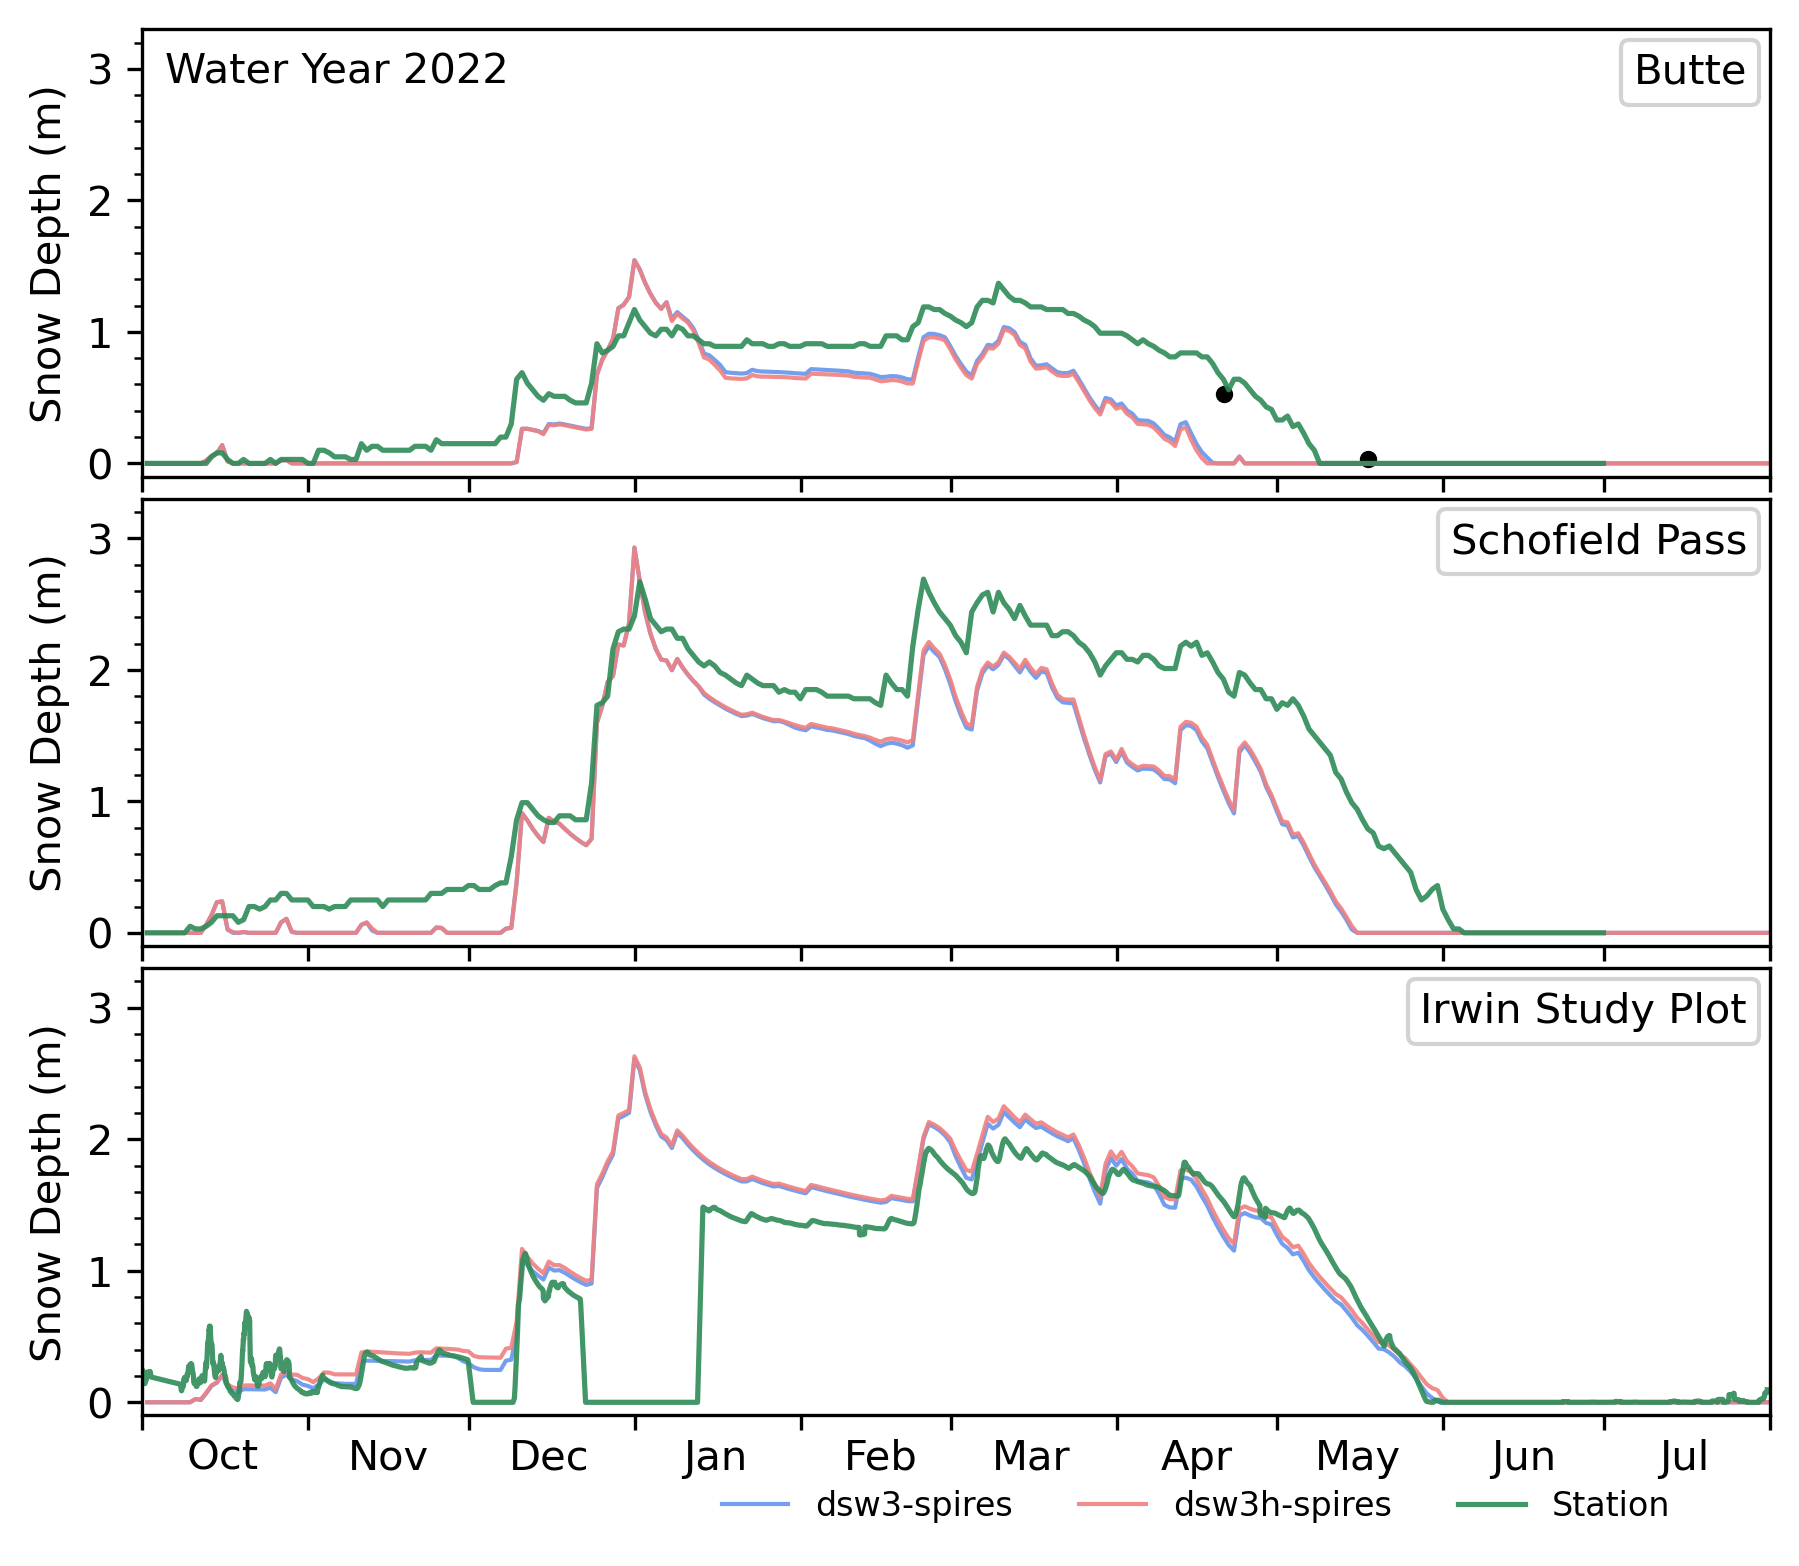

In [28]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,6), dpi=300,)
fig, axes = plt.subplots(3, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        'dsw3-spires': butte_snobal_dsw3['thickness'],
        'dsw3h-spires': butte_snobal_dsw3h['thickness'],
        # 'Time-Decay': butte_snobal['thickness'],
        STATION_LABEL: butte_snotel_csv['Depth(m)'],
    },
    axes[0],
    'Butte'
)

if year == 2022:
    aso_marker=dict(label='ASO', marker='o', c='black', s=10)
    axes[0].scatter(
        [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
        [0.53, 0.03],
        **aso_marker
    )

plot_site(
    {
        'dsw3-spires': schofield_snobal_dsw3['thickness'],
        'dsw3h-spires': schofield_snobal_dsw3h['thickness'],
        # 'Time-Decay': schofield_snobal['thickness'],
        STATION_LABEL: schofield_snotel_csv['Depth(m)'],
    },
    axes[1],
    'Schofield Pass'
)

plot_site(
    {
        'dsw3-spires': irwin_snobal_dsw3['thickness'],
        'dsw3h-spires': irwin_snobal_dsw3h['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[2],
    'Irwin Study Plot'
)
# if year == 2022:
#     axes[1].scatter( [], [], **aso_marker)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes[1].xaxis.set_major_formatter(mticker.NullFormatter())
axes[1].xaxis.set_minor_formatter(xTicks)
axes[1].tick_params(axis='x', which='minor', pad=-0.5)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes[0].add_artist(at)
axes[2].legend(
    frameon=False,
    bbox_to_anchor=(0.95, -0.125),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'mod_snow_slope_station_bias.png', dpi=300, bbox_inches='tight')

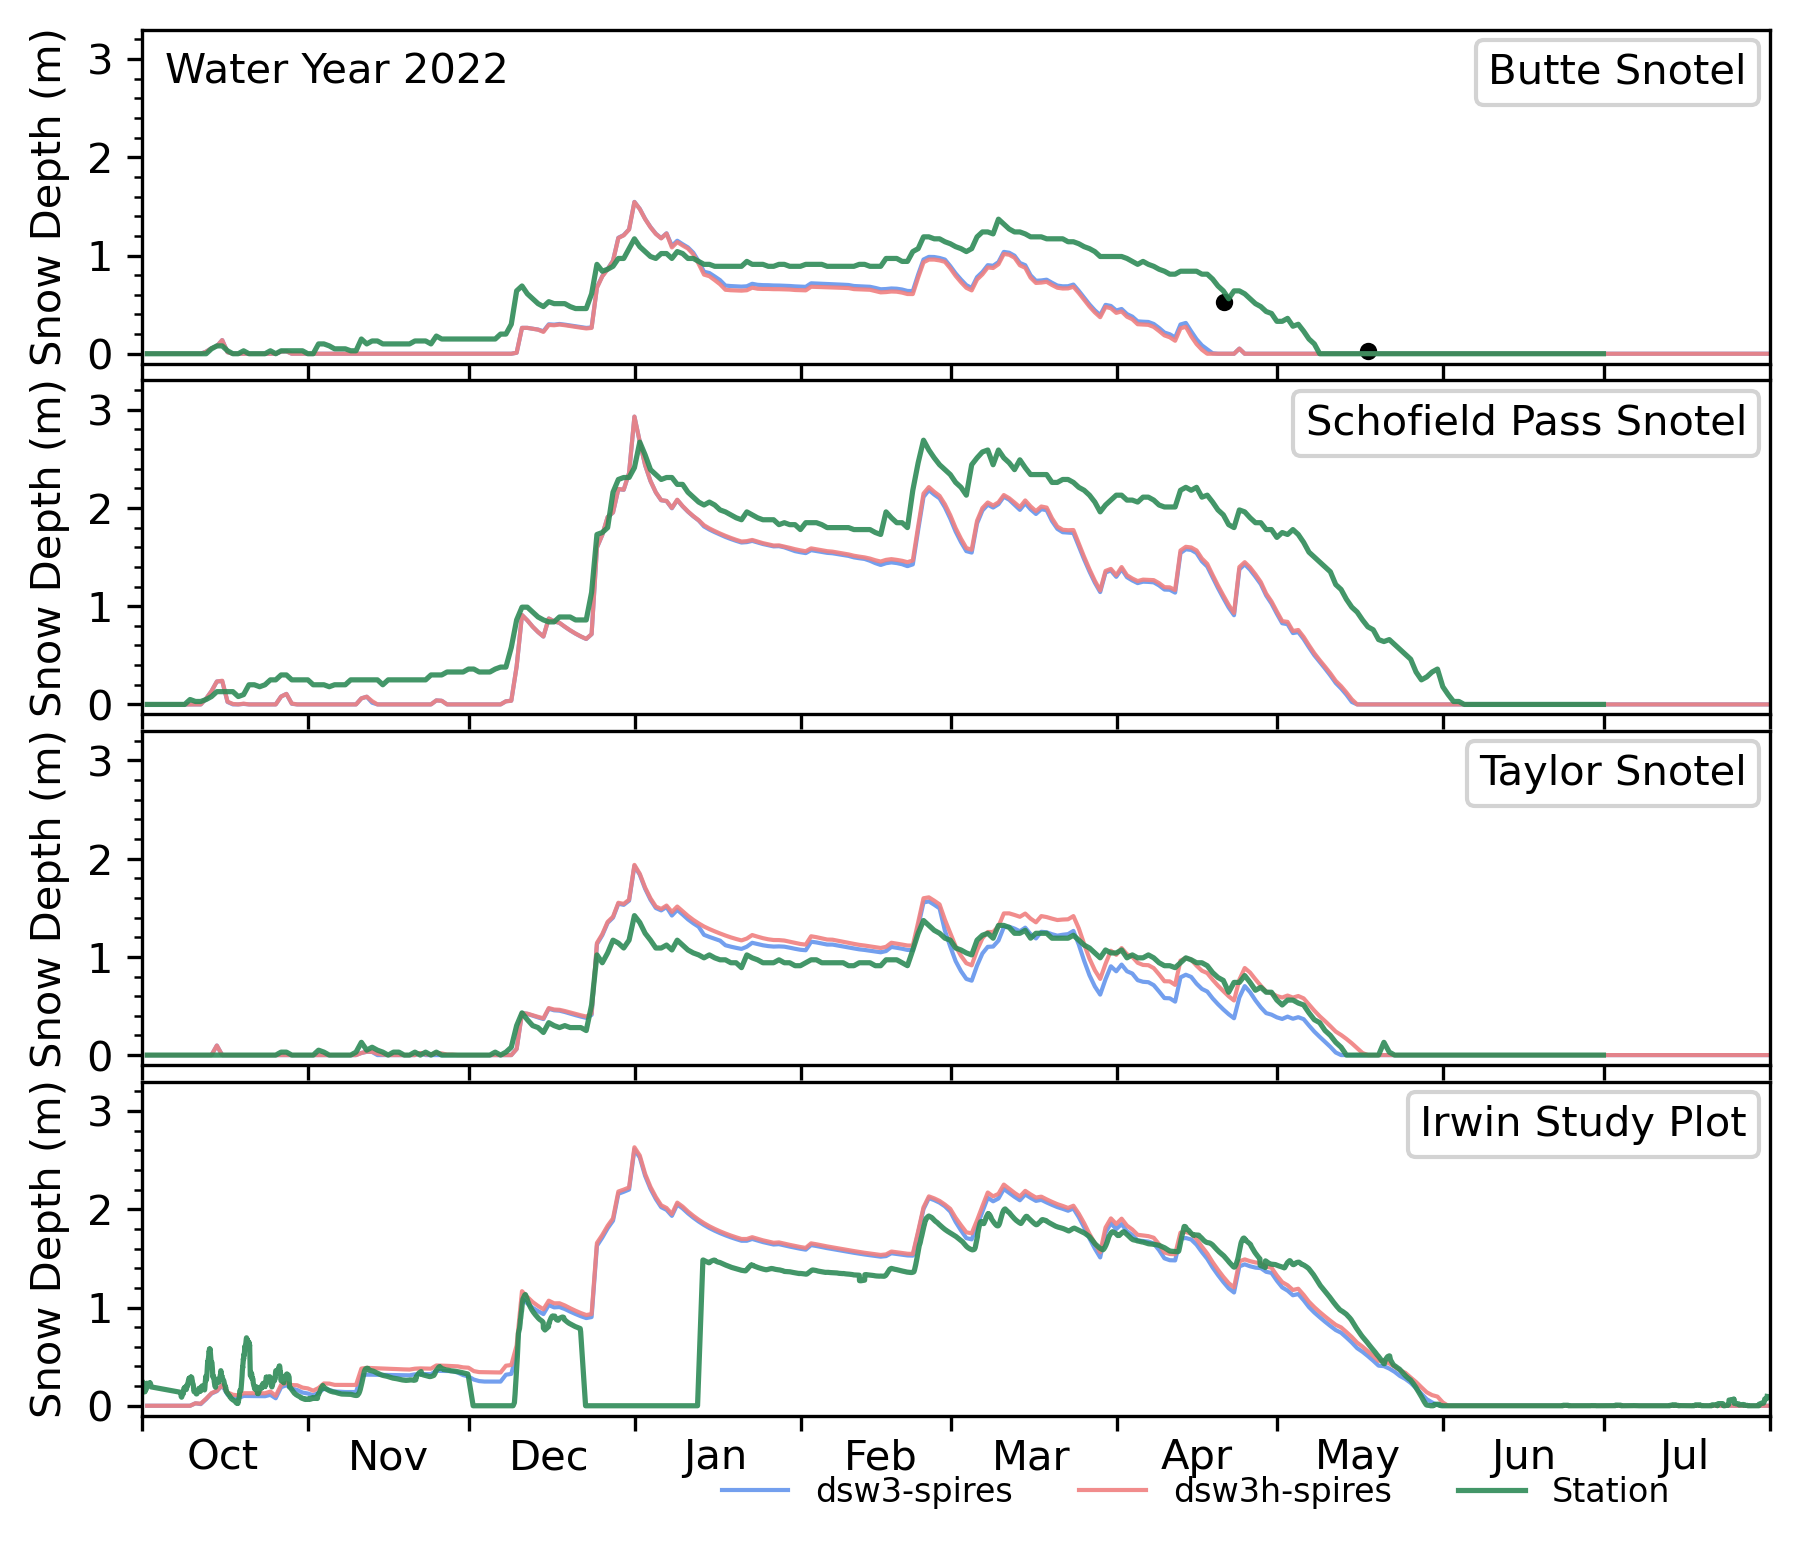

In [33]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,6), dpi=300,)
fig, axes = plt.subplots(4, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        'dsw3-spires': butte_snobal_dsw3['thickness'],
        'dsw3h-spires': butte_snobal_dsw3h['thickness'],
        # 'Time-Decay': butte_snobal['thickness'],
        STATION_LABEL: butte_snotel_csv['Depth(m)'],
    },
    axes[0],
    'Butte Snotel'
)

if year == 2022:
    aso_marker=dict(label='ASO', marker='o', c='black', s=10)
    axes[0].scatter(
        [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
        [0.53, 0.03],
        **aso_marker
    )

plot_site(
    {
        'dsw3-spires': schofield_snobal_dsw3['thickness'],
        'dsw3h-spires': schofield_snobal_dsw3h['thickness'],
        # 'Time-Decay': schofield_snobal['thickness'],
        STATION_LABEL: schofield_snotel_csv['Depth(m)'],
    },
    axes[1],
    'Schofield Pass Snotel'
)

plot_site(
    {
        'dsw3-spires': taylor_snobal_dsw3['thickness'],
        'dsw3h-spires': taylor_snobal_dsw3h['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: taylor_snotel_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[2],
    'Taylor Snotel'
)

plot_site(
    {
        'dsw3-spires': irwin_snobal_dsw3['thickness'],
        'dsw3h-spires': irwin_snobal_dsw3h['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[3],
    'Irwin Study Plot'
)
# if year == 2022:
#     axes[1].scatter( [], [], **aso_marker)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes[1].xaxis.set_major_formatter(mticker.NullFormatter())
axes[1].xaxis.set_minor_formatter(xTicks)
axes[1].tick_params(axis='x', which='minor', pad=-0.5)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes[0].add_artist(at)
axes[3].legend(
    frameon=False,
    bbox_to_anchor=(0.95, -0.125),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/topo-split-rmgsa/"
# plt.savefig(svpth + 'mod_snow2_slope_station_bias.png', dpi=300, bbox_inches='tight')

In [ ]:
# # erw_spires_dsw3_dlwrf/wy2022/erw_50m
# HRRR_solar_0 = xr.open_mfdataset(
#     f'{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/snow.nc',
#     parallel=True, chunks={'time': -1},
#     preprocess=lambda ds: ds['thickness']
# )

In [9]:
butte_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()


In [27]:
del HRRR_solar_0

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.offsetbox import AnchoredText

In [18]:
STATION_LABEL = 'Station'
COLORS = {
        'HRRR-MODIS': 'cornflowerblue',
        'DSW3-SPIRES': 'lightcoral',
        'Time-Decay': 'sandybrown',
        STATION_LABEL: 'seagreen',    
}

def plot_site(data, ax, site_name):
    for key in data:
        if key == STATION_LABEL:
            continue
        
        ax.plot(
            data[key].time,
            data[key].data.flatten(),
            label=key, 
            color=COLORS[key], 
            alpha=0.9, lw=1
        )
    ax.plot(
        data[STATION_LABEL].index,
        data[STATION_LABEL].values,
        label=key, 
        color=COLORS[STATION_LABEL], 
        alpha=0.9, lw=1.25
    ) 
    
    ax.set_ylabel(r'Snow Depth (m)')

    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False)

    ax.set_xlim([plot_range[0], plot_range[-1]])
    ax.set_yticks(np.arange(0, 4))
    ax.set_ylim(bottom=-0.1)
    if year == 2021:
        ax.set_ylim(top=2.4)
    else:
        ax.set_ylim(top=3.3)
        
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.2))
            
    at = AnchoredText(
        site_name, 
        prop=dict(size=10), 
        frameon=True, 
        loc='upper right', 
        pad=0.3, 
        borderpad=0.25,
    )
    at.patch.set_boxstyle("round", pad=0., rounding_size=0.2)
    at.patch.set(edgecolor='lightgrey')
    ax.add_artist(at)

NameError: name 'butte_snobal_hrrr_modis' is not defined

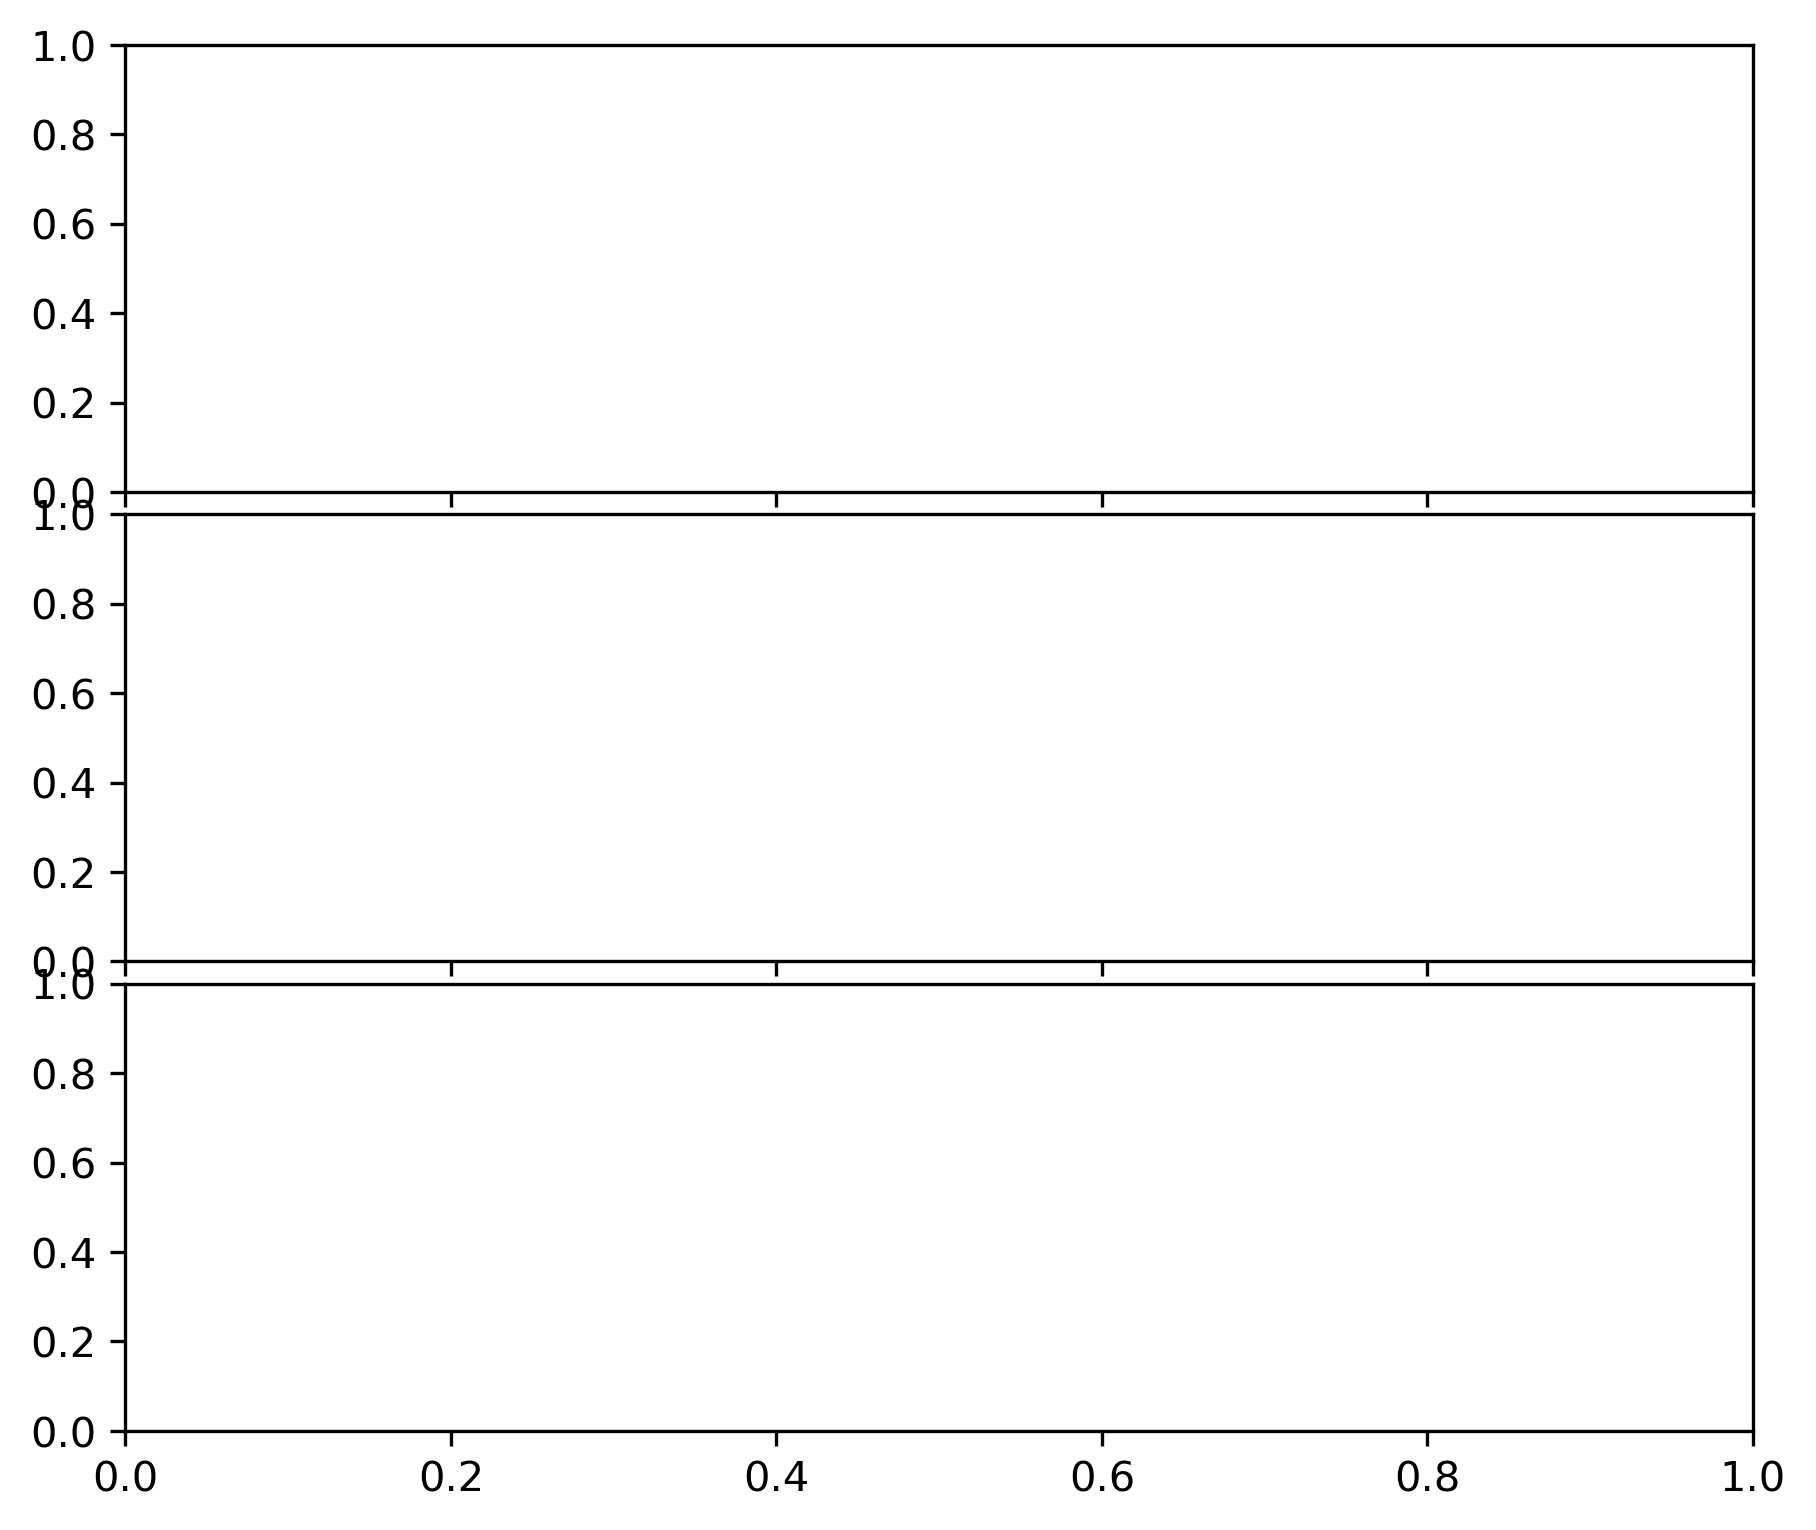

In [30]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,6), dpi=300,)
fig, axes = plt.subplots(3, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        'HRRR-MODIS': butte_snobal_hrrr_modis['thickness'],
        'DSW3-SPIRES': butte_snobal_hrrr['thickness'],
        # 'Time-Decay': butte_snobal['thickness'],
        STATION_LABEL: butte_snotel_csv['Depth(m)'],
    },
    axes[0],
    'Butte'
)

if year == 2022:
    aso_marker=dict(label='ASO', marker='o', c='black', s=10)
    axes[0].scatter(
        [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
        [0.53, 0.03],
        **aso_marker
    )

plot_site(
    {
        'HRRR-MODIS': schofield_snobal_hrrr_modis['thickness'],
        'DSW3-SPIRES': schofield_snobal_hrrr['thickness'],
        # 'Time-Decay': schofield_snobal['thickness'],
        STATION_LABEL: schofield_snotel_csv['Depth(m)'],
    },
    axes[1],
    'Schofield Pass'
)

plot_site(
    {
        # 'HRRR-MODIS': irwin_snobal_hrrr_modis['thickness'],
        'DSW3-SPIRES': irwin_snobal_hrrr['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[2],
    'Irwin Study Plot'
)
# if year == 2022:
#     axes[1].scatter( [], [], **aso_marker)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes[1].xaxis.set_major_formatter(mticker.NullFormatter())
axes[1].xaxis.set_minor_formatter(xTicks)
axes[1].tick_params(axis='x', which='minor', pad=-0.5)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes[0].add_artist(at)
axes[1].legend(
    frameon=False,
    bbox_to_anchor=(0.95, -0.125),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);

In [15]:
schofield_snotel_csv

,Depth(m),SWE(mm),Density(kg/m3),Wind(km/h),Air-T(C),Precipitation (mm)
Date,,,,,,
2021-10-01 22:00:00,0.0,0,NaN,NaN,1.3,10
2021-10-02 22:00:00,0.0,0,NaN,NaN,0.5,0
2021-10-03 22:00:00,0.0,0,NaN,NaN,1.1,0
2021-10-04 22:00:00,0.0,0,NaN,NaN,3.9,0
2021-10-05 22:00:00,0.0,0,NaN,NaN,5.8,0
...,...,...,...,...,...,...
2022-06-26 22:00:00,0.0,0,NaN,NaN,3.8,15
2022-06-27 22:00:00,0.0,0,NaN,NaN,6.5,0
2022-06-28 22:00:00,0.0,0,NaN,NaN,6.8,8


In [16]:
import pandas as pd

# Assuming your dataset is loaded into a DataFrame called df
# For example:
# df = pd.read_csv("your_data.csv", index_col='Date', parse_dates=True)

# Step 1: Find the first occurrence of Depth being 0 and not NaN
depth_zero_index = df[df['Depth(m)'] == 0].dropna(subset=['Depth(m)']).index

# Check if there's an occurrence of Depth 0 and not NaN
if len(depth_zero_index) > 0:
    first_zero_index = depth_zero_index[0]

    # Step 2: Get the last 10 rows before that index
    last_10_before_zero = df.loc[:first_zero_index].iloc[-11:-1]

    # Display the result
    print(last_10_before_zero)
else:
    print("No Depth 0 found or all Depth 0 values are NaN.")


Empty DataFrame
Columns: [Depth(m), SWE(mm), Density(kg/m3), Wind(km/h), Air-T(C), Precipitation (mm)]
Index: []


In [27]:
import pandas as pd

# Assuming the DataFrame `df` is already loaded with the 'Date' as the index
# Example: df = pd.read_csv("your_data.csv", index_col='Date', parse_dates=True)

# Define your start and end dates for the range
start_date = '2022-05-01'
end_date = '2022-06-01'

# Subset the DataFrame based on the date range
subset_df = butte_snotel_csv[start_date:end_date]
# subset_df = schofield_snobal_hrrr[start_date:end_date]

# Display the subset
print(subset_df)


                     Depth(m)  SWE(mm)  Density(kg/m3)  Wind(km/h)  Air-T(C)  \
Date                                                                           
2022-05-01 22:00:00      0.33      147           446.0         NaN      -0.1   
2022-05-02 22:00:00      0.36      147           414.0         NaN       2.3   
2022-05-03 22:00:00      0.28      142           509.0         NaN      -2.7   
2022-05-04 22:00:00      0.30      132           433.0         NaN      -1.2   
2022-05-05 22:00:00      0.23      109           478.0         NaN       4.6   
2022-05-06 22:00:00      0.15       81           533.0         NaN       6.7   
2022-05-07 22:00:00      0.10       51           500.0         NaN       6.1   
2022-05-08 22:00:00      0.00       15             NaN         NaN       5.7   
2022-05-09 22:00:00      0.00        0             NaN         NaN       4.2   
2022-05-10 22:00:00      0.00        0             NaN         NaN       6.2   
2022-05-11 22:00:00      0.00        0  

In [28]:


# import xarray as xr

# # Assuming your xarray dataset is loaded into a variable called `ds`
# # Example: ds = xr.open_dataset("your_dataset.nc")

# # Define the start and end date for your range
# # start_date = '2022-06-01T00:00:00'
# # end_date = '2022-06-10T23:59:59'

# # Subset the data by the time dimension using the `sel` method with the datetime range
# subset_ds = schofield_snobal_hrrr.sel(time=slice(start_date, end_date))

# # Print the subset
# print(subset_ds)

import xarray as xr

# Assuming your xarray dataset is loaded into a variable called `ds`
# Example: ds = xr.open_dataset("your_dataset.nc")

# Define the start and end date for your range
# start_date = '2022-06-01T00:00:00'
# end_date = '2022-06-10T23:59:59'

# Subset the data by the time dimension using the `sel` method with the datetime range
subset_ds = butte_snobal_hrrr.sel(time=slice(start_date, end_date))

# Convert the specific variable (e.g., 'thickness') into a pandas DataFrame
# This assumes that 'thickness' is the variable you want to display
df = subset_ds['thickness'].to_dataframe().reset_index()

# Print the DataFrame (pandas-like table format)
print(df)



                  time          y         x  thickness
0  2022-05-01 22:00:00  4306875.0  330625.0   0.162404
1  2022-05-02 22:00:00  4306875.0  330625.0   0.116500
2  2022-05-03 22:00:00  4306875.0  330625.0   0.062480
3  2022-05-04 22:00:00  4306875.0  330625.0   0.045605
4  2022-05-05 22:00:00  4306875.0  330625.0   0.002126
5  2022-05-06 22:00:00  4306875.0  330625.0   0.000000
6  2022-05-07 22:00:00  4306875.0  330625.0   0.000000
7  2022-05-08 22:00:00  4306875.0  330625.0   0.000000
8  2022-05-09 22:00:00  4306875.0  330625.0   0.000000
9  2022-05-10 22:00:00  4306875.0  330625.0   0.000000
10 2022-05-11 22:00:00  4306875.0  330625.0   0.000000
11 2022-05-12 22:00:00  4306875.0  330625.0   0.000000
12 2022-05-13 22:00:00  4306875.0  330625.0   0.000000
13 2022-05-14 22:00:00  4306875.0  330625.0   0.000000
14 2022-05-15 22:00:00  4306875.0  330625.0   0.000000
15 2022-05-16 22:00:00  4306875.0  330625.0   0.000000
16 2022-05-17 22:00:00  4306875.0  330625.0   0.000000
17 2022-05

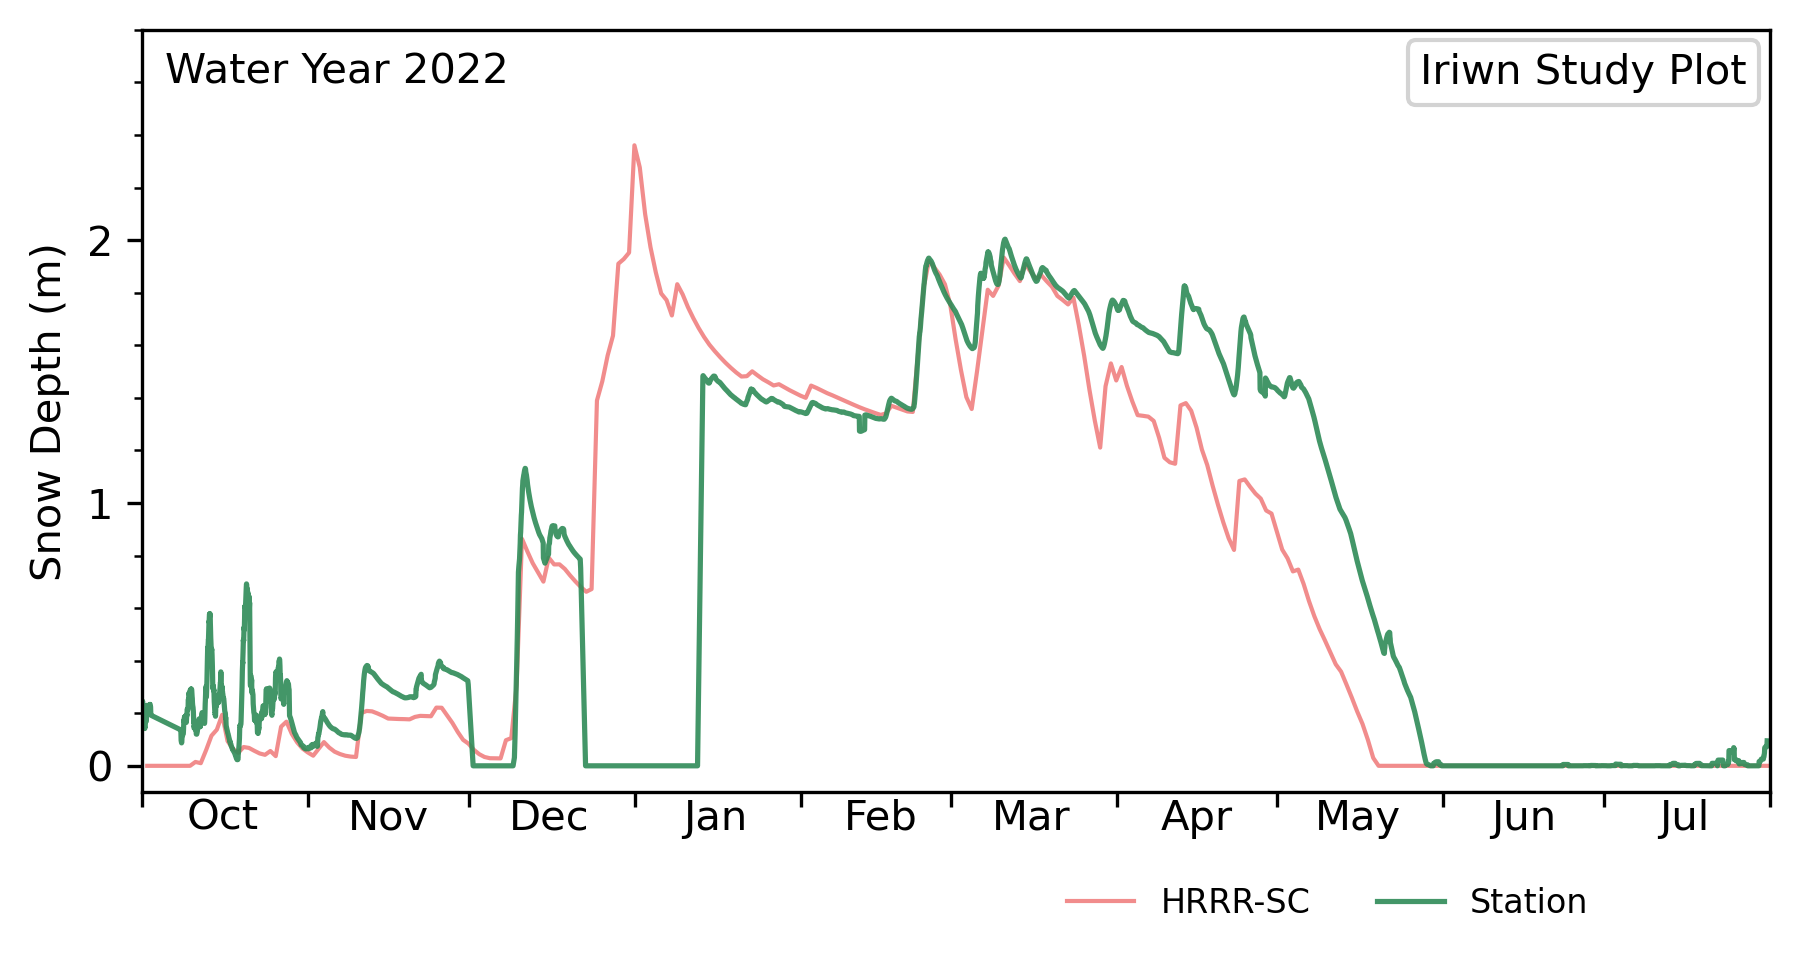

In [21]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,3.3), dpi=300,)
fig, axes = plt.subplots(1, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        # 'HRRR-MODIS': irwin_snobal_hrrr_modis['thickness'],
        'HRRR-SC': irwin_snobal_hrrr['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes,
    'Iriwn Study Plot'
)

axes.xaxis.set_major_locator(mdates.MonthLocator())
axes.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes.xaxis.set_major_formatter(mticker.NullFormatter())
axes.xaxis.set_minor_formatter(xTicks)
axes.tick_params(axis='x', which='minor', pad=-0.5)
axes.set_ylim(top=2.8)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes.add_artist(at)
axes.legend(
    frameon=False,
    bbox_to_anchor=(0.9, -0.1),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);

## test insolation

In [8]:
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit/toposplit_*.nc'

# file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/net_solar.nc"

HRRR_solar = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',
    parallel=True, chunks={'time': 24}, # 'y' :10, 'x': 10},
)

# del HRRR_solar

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33833 instead
  warnings.warn(
Exception ignored in: <function CachingFileManager.__del__ at 0x7ffa0f686fc0>
Traceback (most recent call last):
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2618, in netCDF4._netCDF4.Dataset.close
Exception ignored in: <function CachingFileManager.__del__ at 0x7fe586a76fc0>
Traceback (most recent call last):
  File "/uufs/chpc.uta

In [9]:
HRRR_solar

<xarray.Dataset> Size: 80GB
Dimensions:     (time: 7248, y: 837, x: 656)
Coordinates:
  * x           (x) float32 3kB 3.159e+05 3.16e+05 ... 3.486e+05 3.487e+05
  * y           (y) float32 3kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
  * time        (time) datetime64[ns] 58kB 2021-09-30T06:00:00 ... 2022-08-01...
Data variables:
    ghi         (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    dsw1        (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    dsw2        (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    dsw3        (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    k           (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    projection  (time) |S1 7kB b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
Attributes:
    description:  HRRR topographic split model
    history:      Created 2025-04-21 17:01:58.551783
    source:       HRRR model + custom topo-splitting

In [10]:
irwin_dsw1 = HRRR_solar.dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw3 = HRRR_solar.dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_k = HRRR_solar.k.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


Exception ignored in: <function CachingFileManager.__del__ at 0x7ffa0f686fc0>
Traceback (most recent call last):
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2618, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2585, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2113, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fe586a76fc0>
Traceback (most recent call last):
  File "/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12

In [11]:
irwin_ghi = HRRR_solar.ghi.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


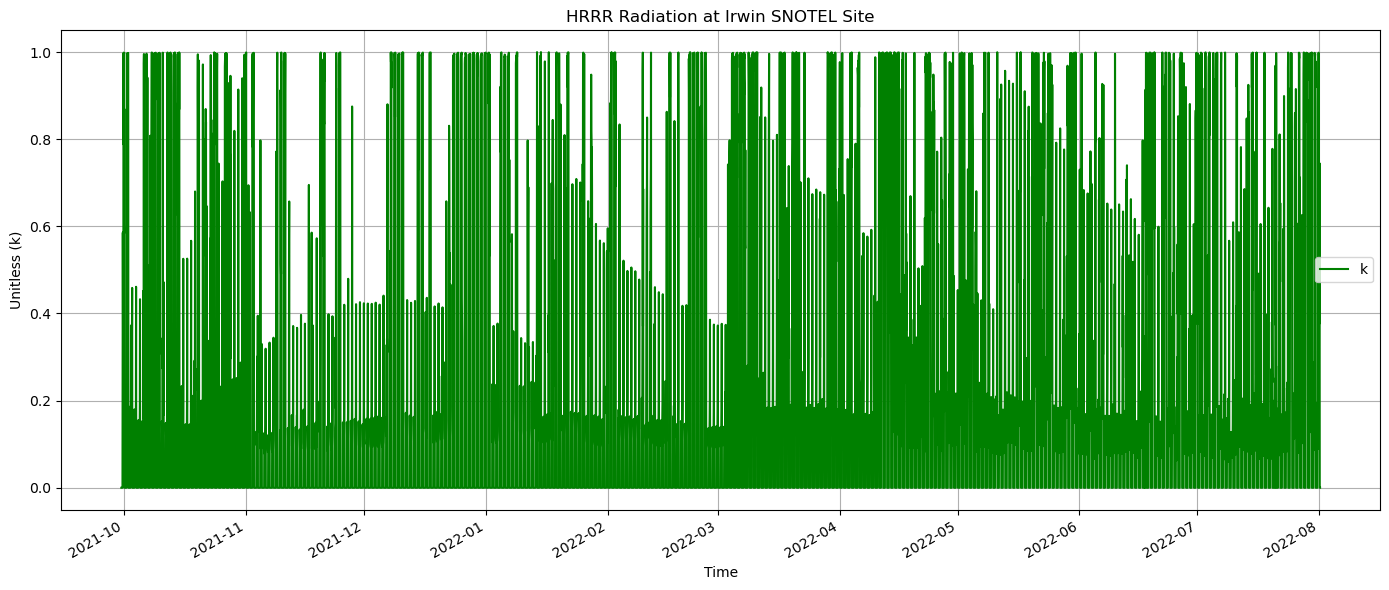

In [9]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each variable
# ax.plot(irwin_dsw1.time, irwin_dsw1, label='DSW1', color='orange')
# ax.plot(irwin_dsw3.time, irwin_dsw3, label='DSW3', color='blue')
ax.plot(irwin_k.time, irwin_k, label='k', color='green')

# Formatting
ax.set_title('HRRR Radiation at Irwin SNOTEL Site')
ax.set_xlabel('Time')
ax.set_ylabel('Radiation (W/m²) or unitless (k)')
ax.set_ylabel('Unitless (k)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


In [26]:


# Use Dask-aware xarray reductions
k = irwin_k

k_stats = {
    'min': k.min().compute().item(),
    'max': k.max().compute().item(),
    'mean': k.mean().compute().item(),
    'median': k.median().compute().item(),
    'std': k.std().compute().item(),
    '25th percentile': k.quantile(0.25).compute().item(),
    '75th percentile': k.quantile(0.75).compute().item(),
    'count (non-NaN)': k.count().compute().item(),
    'NaN count': k.size - k.count().compute().item()
}

# Print nicely
print("Global Statistics for k:")
for key, val in k_stats.items():
    print(f"{key:>18}: {val:.4f}")



Global Statistics for k:
               min: 0.0000
               max: 0.9999
              mean: 0.2087
            median: 0.0000
               std: 0.3326
   25th percentile: 0.0000
   75th percentile: 0.2143
   count (non-NaN): 7320.0000
         NaN count: 0.0000


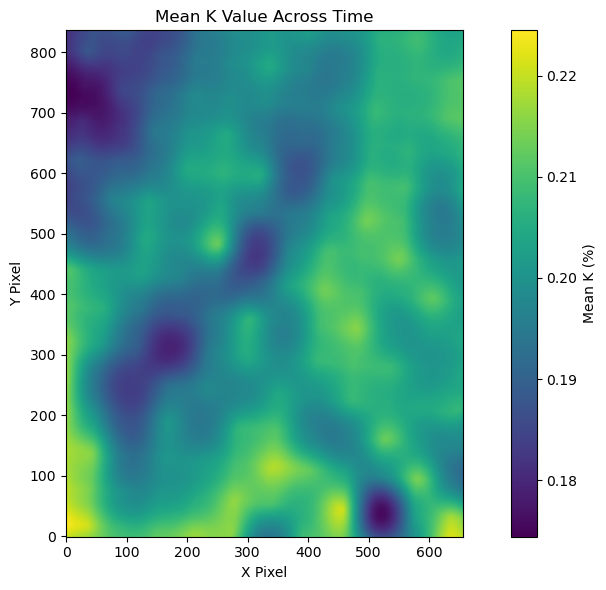

In [12]:
import dask.array as da
import numpy as np
import matplotlib.pyplot as plt

# Assume HRRR_solar is your xarray dataset
# Get the 'k' variable (using Dask array)
k_data = HRRR_solar['k']

# Calculate the mean of 'k' across the time axis (axis 0)
# This will result in a (y, x) array of the mean values
mean_k = k_data.mean(axis=0).compute()  # .compute() triggers the actual computation

# Plot the mean 'k' value (time-averaged) as an image
plt.figure(figsize=(10, 6))
plt.imshow(mean_k, cmap='viridis', origin='lower')
plt.colorbar(label='Mean K (%)')
plt.title('Mean K Value Across Time')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.tight_layout()
plt.show()


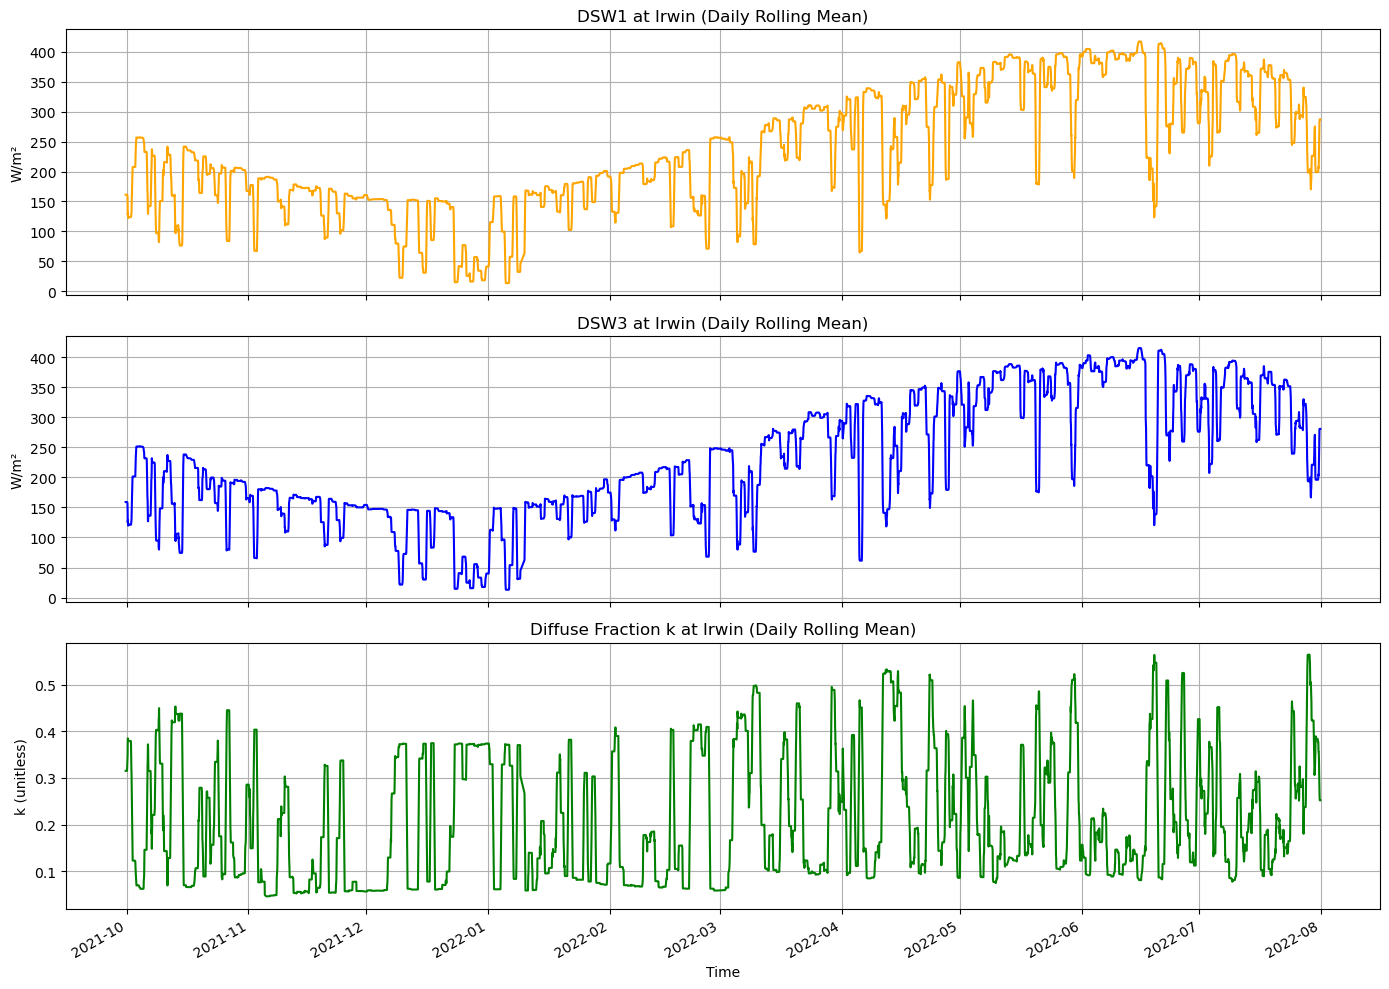

In [13]:
import matplotlib.pyplot as plt

# Apply daily rolling mean (24-hour window)
irwin_dsw1_ = irwin_dsw1.where(irwin_dsw1 > 0 )
irwin_dsw3_ = irwin_dsw3.where(irwin_dsw3 > 0 )
irwin_k_ = irwin_k.where(irwin_k > 0 )

win = 24
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
k_daily = irwin_k.rolling(time=win, center=True).mean()

# Set up the stacked plots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# Plot DSW1
axes[0].plot(dsw1_daily.time, dsw1_daily, color='orange')
axes[0].set_title('DSW1 at Irwin (Daily Rolling Mean)')
axes[0].set_ylabel('W/m²')
axes[0].grid(True)

# Plot DSW3
axes[1].plot(dsw3_daily.time, dsw3_daily, color='blue')
axes[1].set_title('DSW3 at Irwin (Daily Rolling Mean)')
axes[1].set_ylabel('W/m²')
axes[1].grid(True)

# Plot k
axes[2].plot(k_daily.time, k_daily, color='green')
axes[2].set_title('Diffuse Fraction k at Irwin (Daily Rolling Mean)')
axes[2].set_ylabel('k (unitless)')
axes[2].set_xlabel('Time')
axes[2].grid(True)

# Auto format date ticks
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


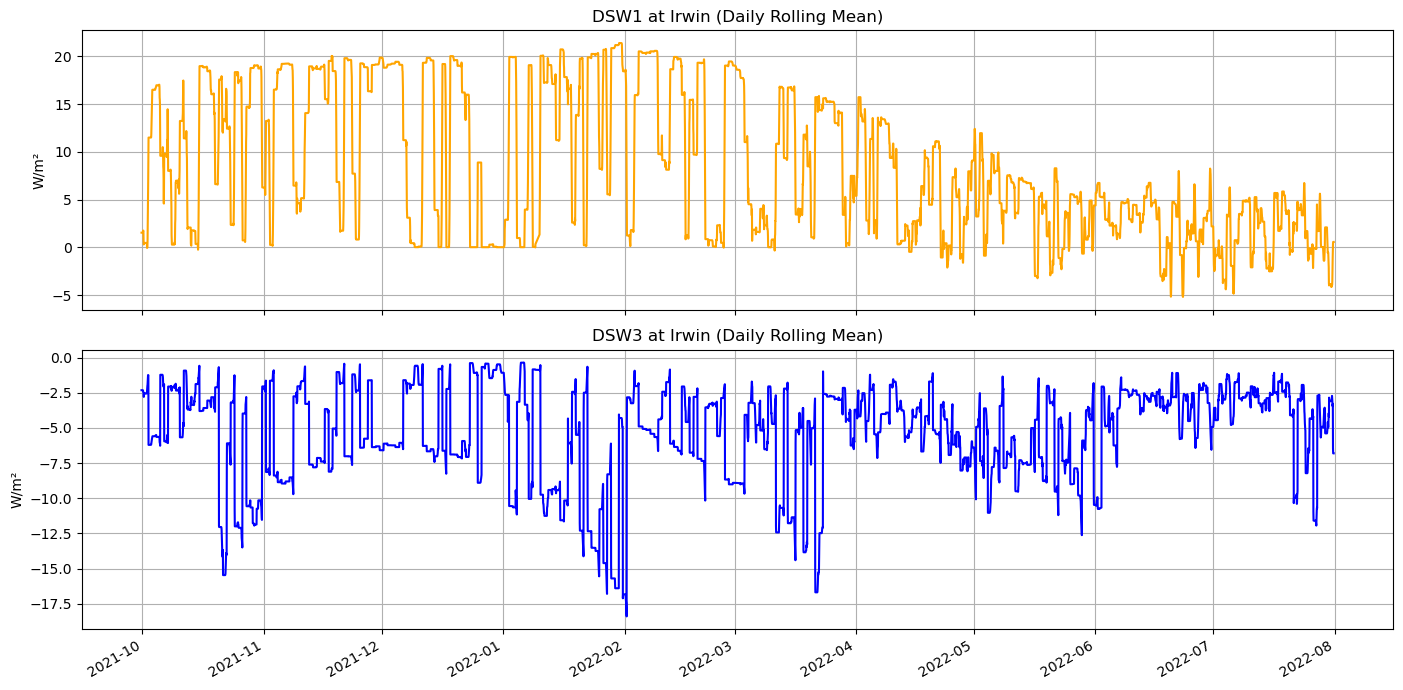

In [14]:
import matplotlib.pyplot as plt


win = 24
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_daily = irwin_ghi.rolling(time=win, center=True).mean()

# Set up the stacked plots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 7), sharex=True)

# Plot DSW1
axes[0].plot(dsw1_daily.time, dsw1_daily-ghi_daily, color='orange')
axes[0].set_title('DSW1 at Irwin (Daily Rolling Mean)')
axes[0].set_ylabel('W/m²')
axes[0].grid(True)

# Plot DSW3
axes[1].plot(dsw3_daily.time,  dsw3_daily-dsw1_daily, color='blue')
axes[1].set_title('DSW3 at Irwin (Daily Rolling Mean)')
axes[1].set_ylabel('W/m²')
axes[1].grid(True)


# Auto format date ticks
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


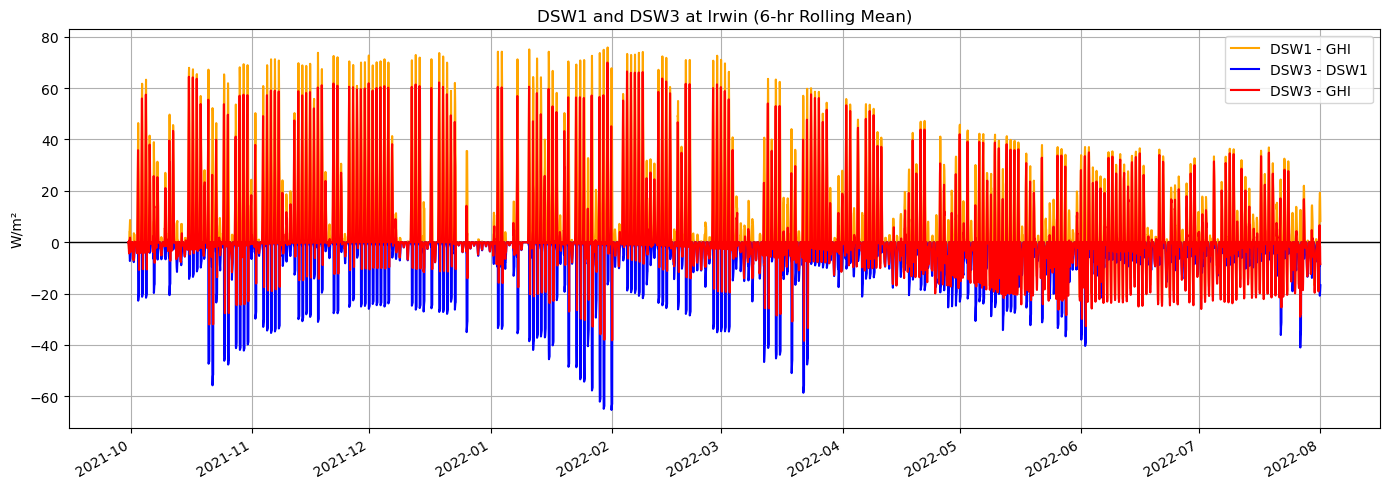

In [15]:

irwin_ghi_ = irwin_dsw3.where(irwin_ghi > 0 )

win = 6
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_daily = irwin_ghi.rolling(time=win, center=True).mean()

# Create a single plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot both series
ax.axhline(0, color='black', linewidth=1)
ax.plot(dsw1_daily.time, dsw1_daily - ghi_daily, label='DSW1 - GHI', color='orange')
ax.plot(dsw3_daily.time, dsw3_daily - dsw1_daily, label='DSW3 - DSW1', color='blue')
ax.plot(dsw3_daily.time, dsw3_daily - ghi_daily, label='DSW3 - GHI', color='red')

# Set titles and labels
ax.set_title('DSW1 and DSW3 at Irwin (6-hr Rolling Mean)')
ax.set_ylabel('W/m²')
ax.grid(True)
ax.legend()

# Auto format date ticks
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


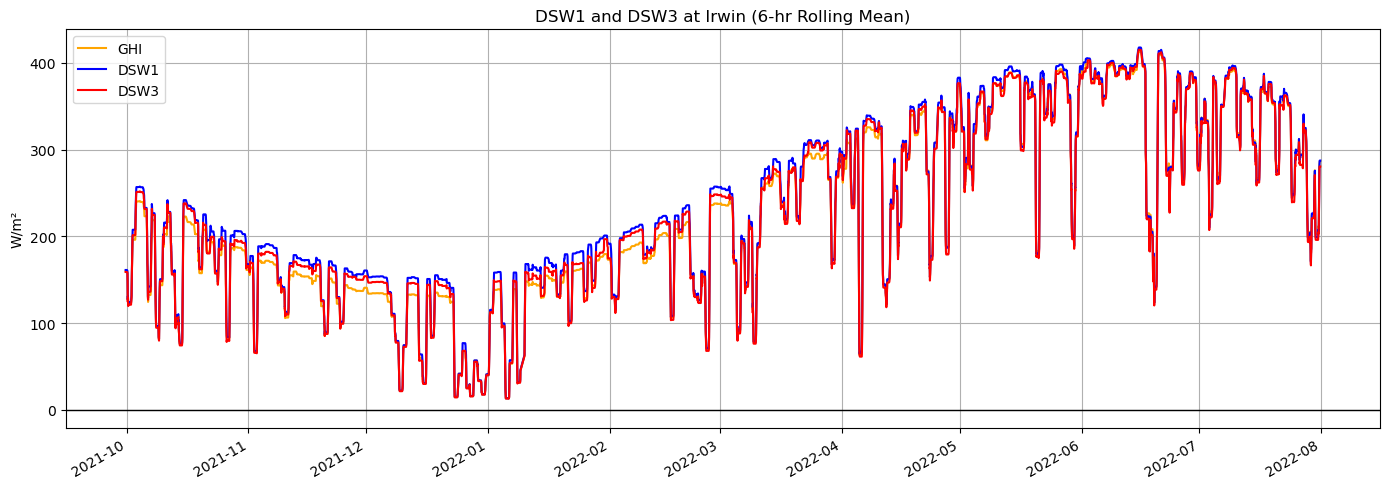

In [16]:

irwin_ghi_ = irwin_dsw3.where(irwin_ghi > 0 )

win = 24
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_daily = irwin_ghi.rolling(time=win, center=True).mean()

# Create a single plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot both series
ax.axhline(0, color='black', linewidth=1)
ax.plot(dsw1_daily.time, ghi_daily, label='GHI', color='orange')
ax.plot(dsw3_daily.time, dsw1_daily, label='DSW1', color='blue')
ax.plot(dsw3_daily.time, dsw3_daily , label='DSW3', color='red')

# Set titles and labels
ax.set_title('DSW1 and DSW3 at Irwin (6-hr Rolling Mean)')
ax.set_ylabel('W/m²')
ax.grid(True)
ax.legend()

# Auto format date ticks
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


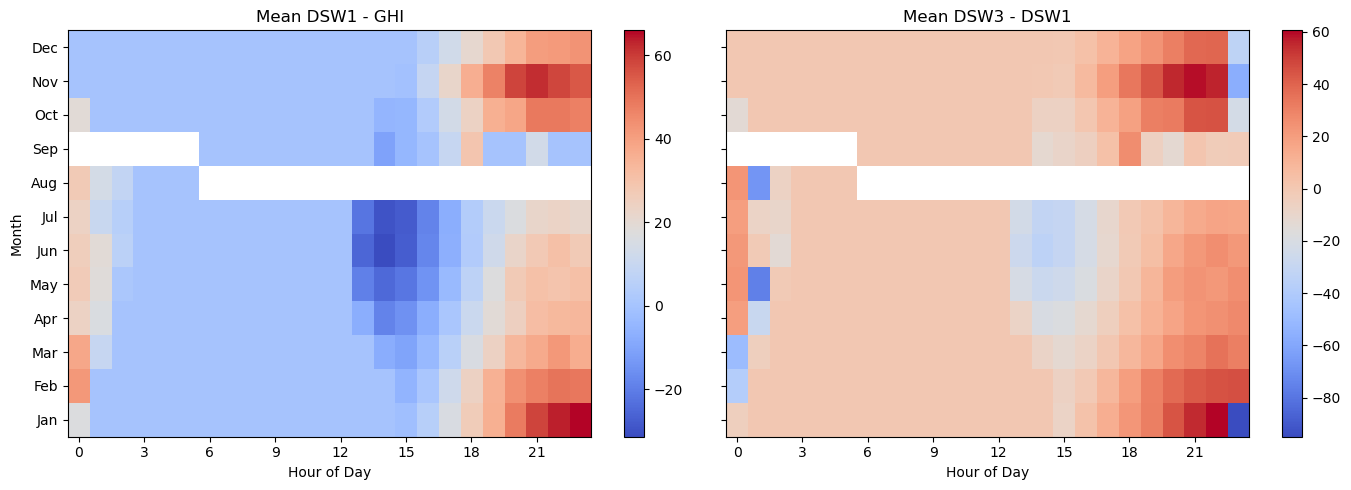

In [17]:
import matplotlib.pyplot as plt
import xarray as xr

# 1. Calculate differences
diff1 = irwin_dsw1 - irwin_ghi
diff2 = irwin_dsw3 - irwin_ghi

# 2. Extract month and hour from time
diff1 = diff1.assign_coords(month=diff1['time.month'], hour=diff1['time.hour'])
diff2 = diff2.assign_coords(month=diff2['time.month'], hour=diff2['time.hour'])

# 3. Group by month and hour
mean_diff1 = diff1.groupby(['month', 'hour']).mean(dim='time')
mean_diff2 = diff2.groupby(['month', 'hour']).mean(dim='time')

# 4. Convert to 2D arrays for heatmaps
mean_diff1_2d = mean_diff1.values.reshape((12, 24))  # 12 months x 24 hours
mean_diff2_2d = mean_diff2.values.reshape((12, 24))

# 5. Plot as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

im1 = axes[0].imshow(mean_diff1_2d, aspect='auto', cmap='coolwarm', origin='lower')
axes[0].set_title('Mean DSW1 - GHI')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Month')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(mean_diff2_2d, aspect='auto', cmap='coolwarm', origin='lower')
axes[1].set_title('Mean DSW3 - DSW1')
axes[1].set_xlabel('Hour of Day')
fig.colorbar(im2, ax=axes[1])

# Set ticks
axes[0].set_xticks(range(0, 24, 3))
axes[1].set_xticks(range(0, 24, 3))
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()


In [ ]:
## COMPARE WITH STATION

In [11]:
PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

In [8]:
import pandas as pd

pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv')

,TIMESTAMP,Temp_c,Incoming_Solar_Wm2_1_Avg,Incoming_NIR_Wm2_2_Avg,Outgoing_Solar_Wm2_3_Avg,Outoging_NIR_Wm2_4_Avg
0,10/1/2021 0:00,5.548,39.85382,17.030550,5.470381,4.279513
1,10/1/2021 0:15,5.140,6.828979,2.342873,2.172731,2.028989
2,10/1/2021 0:30,4.385,8.205617,3.107446,2.742686,2.575902
3,10/1/2021 0:45,3.870,9.387377,3.996677,1.904299,1.689760
4,10/1/2021 1:00,3.420,3.038141,1.243343,1.019547,0.926260
...,...,...,...,...,...,...
25686,6/25/2022 13:30,1.267,67.80714,19.912140,9.272700,6.692386
25687,6/25/2022 13:45,1.821,274.0498,124.711700,26.574190,21.086890
25688,6/25/2022 14:00,4.256,340.6974,167.584100,45.274410,36.379280
25689,6/25/2022 14:15,7.532,382.882,191.219500,58.465750,46.475040


In [9]:
PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)
irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])
irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

# add net solar
# removed
# ROLL_WINDOW = 32
# .rolling(ROLL_WINDOW).mean().interpolate('time')
irwin_pyra['net_solar'] = (
    # irwin_pyra['VIS_IN'] + irwin_pyra['NIR_IN'] - irwin_pyra['VIS_OUT'] - irwin_pyra['NIR_OUT']
    irwin_pyra['VIS_IN']
)
irwin_pyra['albedo'] = (
    (0.67 * (irwin_pyra['VIS_OUT'] / irwin_pyra['VIS_IN'])) + (0.33 * (irwin_pyra['NIR_OUT'] / irwin_pyra['NIR_IN']))
)

irwin_pyra

,Temp,VIS_IN,NIR_IN,VIS_OUT,NIR_OUT,net_solar,albedo
2021-10-01 00:00:00,5.548,39.853820,17.030550,5.470381,4.279513,39.853820,0.174889
2021-10-01 00:15:00,5.140,6.828979,2.342873,2.172731,2.028989,6.828979,0.498958
2021-10-01 00:30:00,4.385,8.205617,3.107446,2.742686,2.575902,8.205617,0.497496
2021-10-01 00:45:00,3.870,9.387377,3.996677,1.904299,1.689760,9.387377,0.275436
2021-10-01 01:00:00,3.420,3.038141,1.243343,1.019547,0.926260,3.038141,0.470682
...,...,...,...,...,...,...,...
2022-06-25 13:30:00,1.267,67.807140,19.912140,9.272700,6.692386,67.807140,0.202535
2022-06-25 13:45:00,1.821,274.049800,124.711700,26.574190,21.086890,274.049800,0.120767
2022-06-25 14:00:00,4.256,340.697400,167.584100,45.274410,36.379280,340.697400,0.160671
2022-06-25 14:15:00,7.532,382.882000,191.219500,58.465750,46.475040,382.882000,0.182513


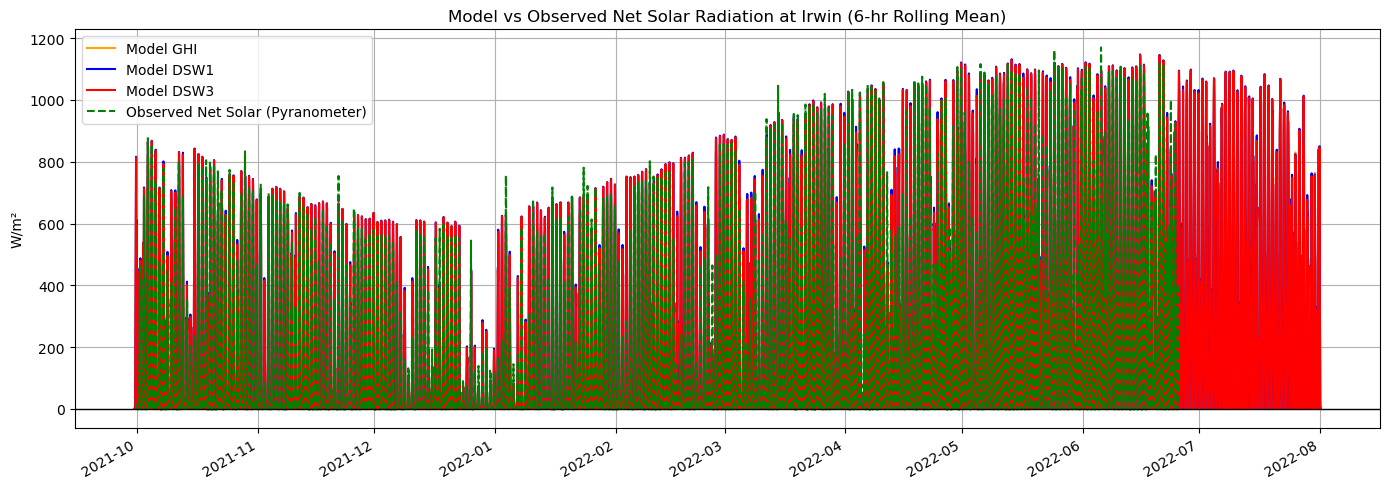

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Define start and end of Water Year 2022
start_wy2022 = '2021-10-01'
end_wy2022   = '2022-09-30'

# Subset the DataFrame
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
# irwin_pyra_wy2022 = irwin_pyra_hourly.loc[start_wy2022 : end_wy2022]
irwin_pyra_hourly_wy2022 = irwin_pyra_hourly.loc['2021-10-01':'2022-09-30']



# Make sure the index of irwin_pyra is datetime
# Resample to hourly means
irwin_pyra_hourly_wy2022.index = pd.to_datetime(irwin_pyra_hourly_wy2022.index)

# Smooth the observed net solar radiation (e.g. 6-hour window = 24 points for 15-min data)
obs_net_solar = irwin_pyra_hourly_wy2022['VIS_IN'].rolling(window=1, center=True).mean()
obs_net_solar_ = obs_net_solar.where(obs_net_solar > 0 )

# Rolling mean for model outputs
win = 1
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_daily  = irwin_ghi.rolling(time=win, center=True).mean()

# Create the plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot model outputs
ax.plot(dsw1_daily.time, ghi_daily, label='Model GHI', color='orange')
ax.plot(dsw1_daily.time, dsw1_daily, label='Model DSW1', color='blue')
ax.plot(dsw3_daily.time, dsw3_daily, label='Model DSW3', color='red')

# Plot station observation
ax.plot(obs_net_solar.index, obs_net_solar, label='Observed Net Solar (Pyranometer)', color='green', linestyle='--')

# Add zero reference line
ax.axhline(0, color='black', linewidth=1)

# Add labels, legend, formatting
ax.set_title('Model vs Observed Net Solar Radiation at Irwin (6-hr Rolling Mean)')
ax.set_ylabel('W/m²')
ax.grid(True)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


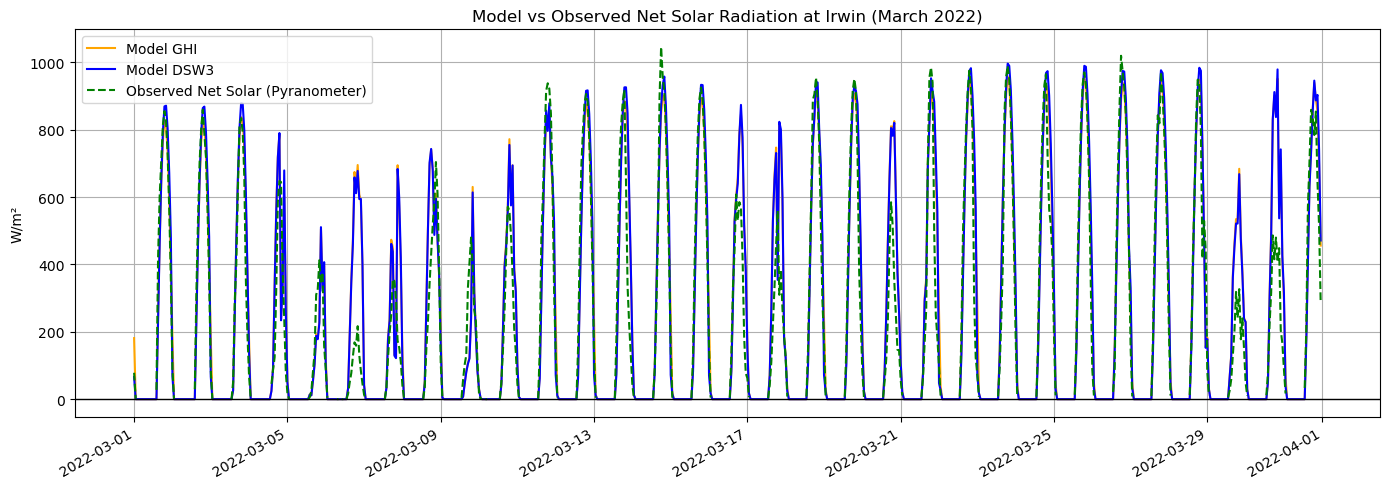

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
irwin_pyra.index = pd.to_datetime(irwin_pyra.index)

# Resample to hourly data
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()

# Subset to Water Year 2022
irwin_pyra_hourly_wy2022 = irwin_pyra_hourly.loc['2021-10-01':'2022-09-30']

# Filter for March only
irwin_pyra_march = irwin_pyra_hourly_wy2022[irwin_pyra_hourly_wy2022.index.month == 3]

# Filter model data to March (assuming xarray format)
march_mask = (dsw1_daily['time.month'] == 3) & (dsw1_daily['time.year'] == 2022)
dsw1_march = dsw1_daily.sel(time=march_mask)
dsw3_march = dsw3_daily.sel(time=march_mask)
ghi_march  = ghi_daily.sel(time=march_mask)

# Get March observational net solar
obs_net_solar_march = irwin_pyra_march['VIS_IN']
obs_net_solar_march = obs_net_solar_march.where(obs_net_solar_march > 0)  # filter negatives

# Plotting
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ghi_march.time, ghi_march, label='Model GHI', color='orange')
# ax.plot(dsw1_march.time, dsw1_march, label='Model DSW1', color='blue')
ax.plot(dsw3_march.time, dsw3_march, label='Model DSW3', color='blue')
ax.plot(obs_net_solar_march.index, obs_net_solar_march, label='Observed Net Solar (Pyranometer)', color='green', linestyle='--')

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Model vs Observed Net Solar Radiation at Irwin (March 2022)')
ax.set_ylabel('W/m²')
ax.grid(True)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [31]:
import pandas as pd

idf = pd.read_csv('/uufs/chpc.utah.edu/common/home/u1037042/Documents/isnobal_data/irwin/Irwin_USGS.csv')

# Load the CSV (adjust the filename as needed)
# idf = pd.read_csv('idf.csv')
# Select only the required columns
idf = idf[['datetime', '307700_72175', '307704_72186']]

# Rename the columns for convenience
idf = idf.rename(columns={
    '307700_72175': 'Longwave_down',
    '307704_72186': 'Shortwave_down'
})

# Cap Shortwave_down values between 0 and 1300 W/m²
idf['Shortwave_down'] = idf['Shortwave_down'].clip(lower=0, upper=1300)

# Convert 'datetime' to pandas datetime format
idf['datetime'] = pd.to_datetime(idf['datetime'], format='%m/%d/%y %H:%M')

# Convert timezone from the 'tz_cd' column (MST to UTC)
# Assuming 'MST' is the timezone, you can change it to your required timezone (e.g., UTC)
idf['datetime'] = idf['datetime'].dt.tz_localize('MST').dt.tz_convert('UTC')
idf

,datetime,Longwave_down,Shortwave_down
0,2022-02-01 07:00:00+00:00,207.0,0.00
1,2022-02-01 08:00:00+00:00,206.0,0.00
2,2022-02-01 09:00:00+00:00,205.0,0.00
3,2022-02-01 10:00:00+00:00,206.0,0.00
4,2022-02-01 11:00:00+00:00,209.0,0.00
...,...,...,...
1434,2022-04-02 02:00:00+00:00,242.0,56.40
1435,2022-04-02 03:00:00+00:00,229.0,5.86
1436,2022-04-02 04:00:00+00:00,223.0,0.00
1437,2022-04-02 05:00:00+00:00,221.0,0.00


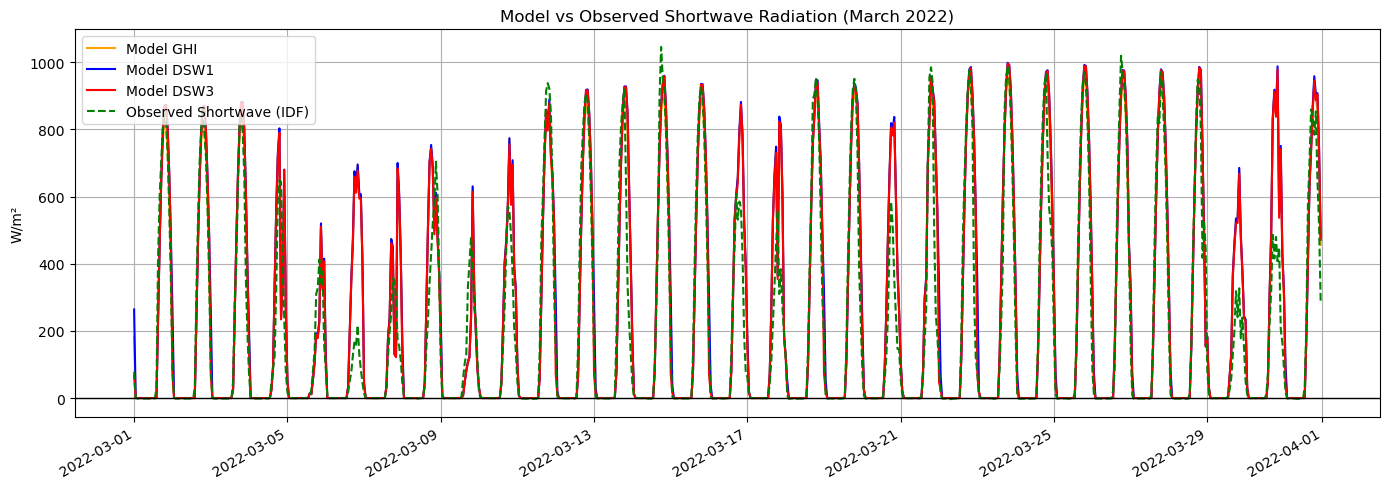

In [28]:
# Resample to hourly if needed (optional, depending on model resolution)
# idf_hourly = idf.set_index('datetime').resample('1h').mean()

# Filter to March 2022
# idf_march = idf_hourly.loc['2022-03-01':'2022-03-31']
idf_march = irwin_pyra_hourly.loc['2022-03-01':'2022-03-31']

# === 2. Prepare Model Data ===
# Rolling (1 means hourly in your case; no smoothing)
win = 1
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_daily  = irwin_ghi.rolling(time=win, center=True).mean()

# Select March 2022 from model data
march_mask = (dsw1_daily['time.month'] == 3) & (dsw1_daily['time.year'] == 2022)
dsw1_march = dsw1_daily.sel(time=march_mask)
dsw3_march = dsw3_daily.sel(time=march_mask)
ghi_march  = ghi_daily.sel(time=march_mask)


# === 3. Plot Comparison ===
fig, ax = plt.subplots(figsize=(14, 5))

# Plot model outputs
ax.plot(ghi_march.time, ghi_march, label='Model GHI', color='orange')
ax.plot(dsw1_march.time, dsw1_march, label='Model DSW1', color='blue')
ax.plot(dsw3_march.time, dsw3_march, label='Model DSW3', color='red')

# Plot station observation
ax.plot(idf_march.index, idf_march['VIS_IN'], label='Observed Shortwave (IDF)', color='green', linestyle='--')

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Model vs Observed Shortwave Radiation (March 2022)')
ax.set_ylabel('W/m²')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [42]:
import pandas as pd

# Load your CSV (if needed)
# idf = pd.read_csv('your_file.csv')
idf = pd.read_csv('/uufs/chpc.utah.edu/common/home/u1037042/Documents/isnobal_data/irwin/Irwin_USGS.csv')

# Keep only relevant columns
idf = idf[['datetime', 'tz_cd', '307700_72175', '307704_72186']]

# Rename for convenience
idf = idf.rename(columns={
    '307700_72175': 'Longwave_down',
    '307704_72186': 'Shortwave_down'
})

# Cap shortwave values
idf['Shortwave_down'] = idf['Shortwave_down'].clip(lower=0, upper=1300)

# Parse datetime
idf['datetime'] = pd.to_datetime(idf['datetime'], format='%m/%d/%y %H:%M')

# Localize to America/Denver, which handles both MST and MDT correctly
idf['datetime'] = idf['datetime'].dt.tz_localize('America/Denver', ambiguous='NaT')

# Convert to UTC
idf['datetime'] = idf['datetime'].dt.tz_convert('UTC')

# Resample to hourly average
idf_hourly = idf.set_index('datetime')[['Longwave_down', 'Shortwave_down']].resample('1h').mean()

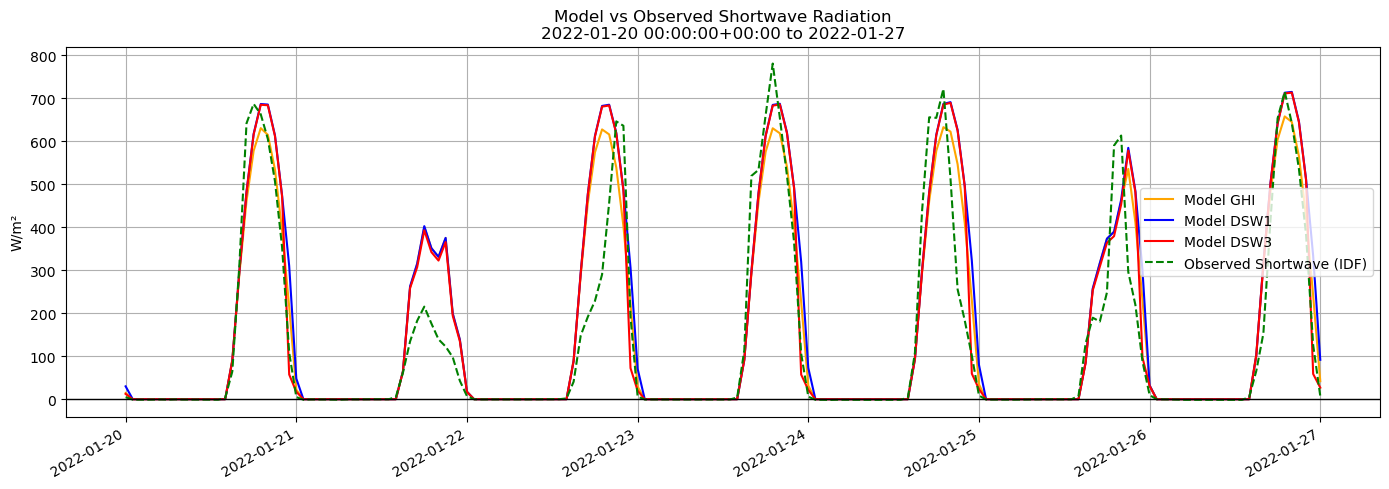

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

# === 1. Set date range inputs ===
start_date = pd.to_datetime('2022-01-20').tz_localize('UTC')
num_days = 7
end_date = start_date + timedelta(days=num_days)

# Use tz-naive copies for slicing xarray model data
start_naive = start_date.tz_convert(None)
end_naive = end_date.tz_convert(None)



# Subset by input date range
# idf_subset = idf_hourly.loc[start_date:end_date]
idf_subset = irwin_pyra_hourly.loc[start_naive:end_naive]



# === 3. Prepare Model Data ===
win = 1  # no smoothing
dsw1_rolling = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_rolling = irwin_dsw3.rolling(time=win, center=True).mean()
ghi_rolling  = irwin_ghi.rolling(time=win, center=True).mean()

# Subset model data using tz-naive timestamps
dsw1_subset = dsw1_rolling.sel(time=slice(start_naive, end_naive))
dsw3_subset = dsw3_rolling.sel(time=slice(start_naive, end_naive))
ghi_subset  = ghi_rolling.sel(time=slice(start_naive, end_naive))



# === 4. Plot ===
fig, ax = plt.subplots(figsize=(14, 5))

# Plot model outputs
ax.plot(ghi_subset.time, ghi_subset, label='Model GHI', color='orange')
ax.plot(dsw1_subset.time, dsw1_subset, label='Model DSW1', color='blue')
ax.plot(dsw3_subset.time, dsw3_subset, label='Model DSW3', color='red')

# Plot station observation
ax.plot(idf_subset.index, idf_subset['VIS_IN'], label='Observed Shortwave (IDF)', color='green', linestyle='--')

# Styling
ax.axhline(0, color='black', linewidth=1)
ax.set_title(f'Model vs Observed Shortwave Radiation\n{start_date} to {end_date.date()}')
ax.set_ylabel('W/m²')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Biggest issue with validation of Irwin is that there appears to be a

In [ ]:
# INSPECT SAIL DATA!

## Multiple at a time

In [ ]:
solar_SMRF = xr.open_mfdataset(
    f'{S_STORE}/net_dswrf.MST.*.nc',
    parallel=True, chunks={'time': -1},
    preprocess=lambda ds: ds['thickness'],
)

butte_snobal = solar_SMRF.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal = solar_SMRF.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal = solar_SMRF.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal = solar_SMRF.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

del solar_SMRF